# Тема: Искусственный нейрон и однослойный перцептрон


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Задание 1: реализация функций активации

In [2]:
# Clip'ы против overflow (на всякий случай)

def identity(x: np.ndarray) -> np.ndarray: 
    # Тождественная
    return x

def step(x: np.ndarray) -> np.ndarray: 
    # Единичная ступенька
    f = lambda x: 1. if x >= 0. else 0.
    return np.vectorize(f)(x)

def sigmoid(x: np.ndarray) -> np.ndarray:
    # Логистическая
    f = lambda x: 1. / (1. + np.exp(-x))
    return np.vectorize(f)(np.clip(x, -700., 700.))

def tanh(x: np.ndarray) -> np.ndarray:
    # Гиперболический тангенс
    x_clipped = np.clip(x, -700., 700.)
    posexp = np.exp(x_clipped)
    negexp = np.exp(-x_clipped)
    return (posexp - negexp) / (posexp + negexp)

def arctan(x: np.ndarray) -> np.ndarray:
    # Арктангенс
    return np.arctan(x)

def relu(x: np.ndarray) -> np.ndarray:
    f = lambda x: max(0., x)
    return np.vectorize(f)(x)

# Определяем исходные данные

In [3]:
def neuron_output(X, w, b, act_f):
    # Добавил тут функцию активации на выбор
    z = np.dot(X, w) + b
    return act_f(z)

In [4]:
SIZE = 100
SEED = 1112
LEARNING_RATE = 0.01
EPOCHS = 10

In [5]:
np.random.seed(SEED)

class_1 = np.random.randn(SIZE, 2) + np.array([-2, -2])
class_2 = np.random.randn(SIZE, 2) + np.array([2, 2])

X = np.vstack((class_1, class_2))
y = np.array([0]*SIZE + [1]*SIZE)

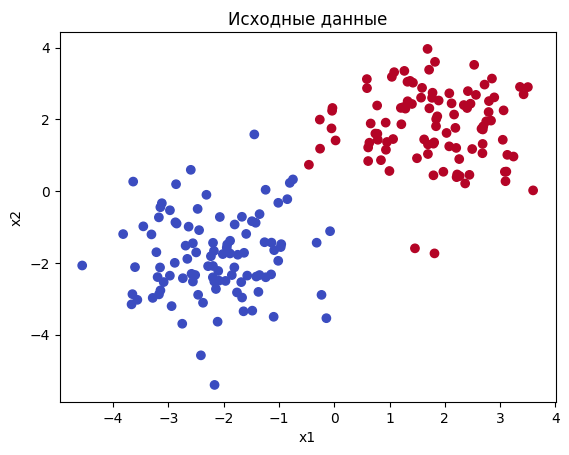

In [6]:
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')
plt.title('Исходные данные')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [7]:
def plot_decision_boundary(w, b, act_f):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    Z = neuron_output(np.c_[xx.ravel(), yy.ravel()], w, b, act_f)
    Z = Z.reshape(xx.shape)

    # Тут проверяем на >= 0.5, поскольку предсказания с 
    # другими функциями активации могут не быть бинарными
    Z = (Z >= 0.5).astype(int)

    plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.2, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    plt.title(f'Граница решений однослойного перцептрона с функцией активации {act_f.__name__}')
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.show()

# Задание 2: Смотрим, как изменяется поведение однослойного перцептрона при изменении функции активации

In [8]:
def launch_learning_process(act_f):
    w = np.random.randn(2)
    b = 0.0

    for epoch in range(EPOCHS):
        for i in range(len(X)):
            z = np.dot(X[i], w) + b
            y_pred = act_f(z)
            error = y[i] - y_pred
            w += LEARNING_RATE * error * X[i]
            b += LEARNING_RATE * error
        preds = np.array([act_f(x @ w + b) for x in X])

        # Тут проверяем на >= 0.5, поскольку предсказания с 
        # другими функциями активации могут не быть бинарными
        acc = ((preds >= 0.5).astype(int) == y).mean() 

        print(f"Эпоха {epoch+1}/{EPOCHS} — точность: {acc:.4f}")

    return plot_decision_boundary(w, b, act_f)

Эпоха 1/10 — точность: 0.8850
Эпоха 2/10 — точность: 0.9500
Эпоха 3/10 — точность: 0.9800
Эпоха 4/10 — точность: 0.9900
Эпоха 5/10 — точность: 1.0000
Эпоха 6/10 — точность: 1.0000
Эпоха 7/10 — точность: 0.9950
Эпоха 8/10 — точность: 0.9950
Эпоха 9/10 — точность: 0.9950
Эпоха 10/10 — точность: 0.9950


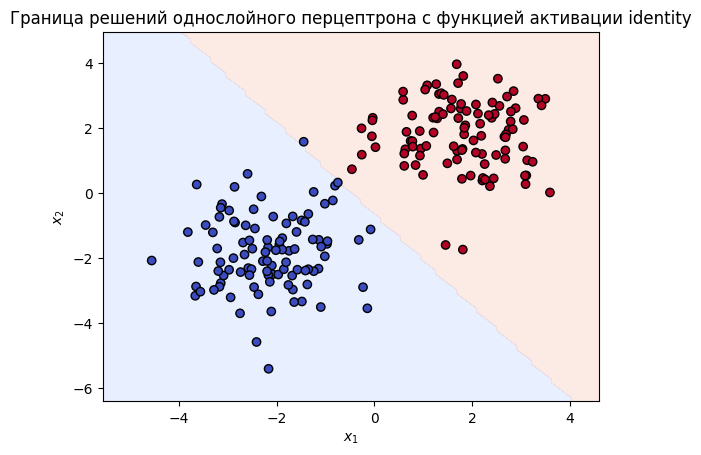

In [9]:
launch_learning_process(identity)


Эпоха 1/10 — точность: 0.9750
Эпоха 2/10 — точность: 0.9850
Эпоха 3/10 — точность: 0.9850
Эпоха 4/10 — точность: 0.9850
Эпоха 5/10 — точность: 0.9850
Эпоха 6/10 — точность: 0.9900
Эпоха 7/10 — точность: 0.9950
Эпоха 8/10 — точность: 0.9900
Эпоха 9/10 — точность: 0.9950
Эпоха 10/10 — точность: 0.9950


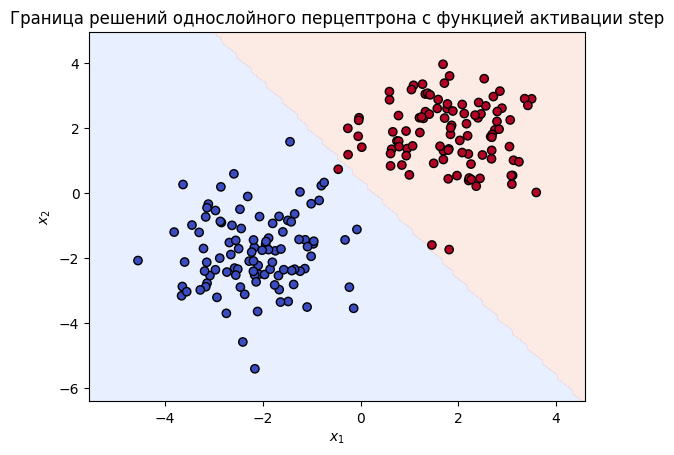

In [10]:
launch_learning_process(step)

Эпоха 1/10 — точность: 0.9850
Эпоха 2/10 — точность: 0.9850
Эпоха 3/10 — точность: 0.9850
Эпоха 4/10 — точность: 0.9850
Эпоха 5/10 — точность: 0.9850
Эпоха 6/10 — точность: 0.9850
Эпоха 7/10 — точность: 0.9850
Эпоха 8/10 — точность: 0.9850
Эпоха 9/10 — точность: 0.9850
Эпоха 10/10 — точность: 0.9850


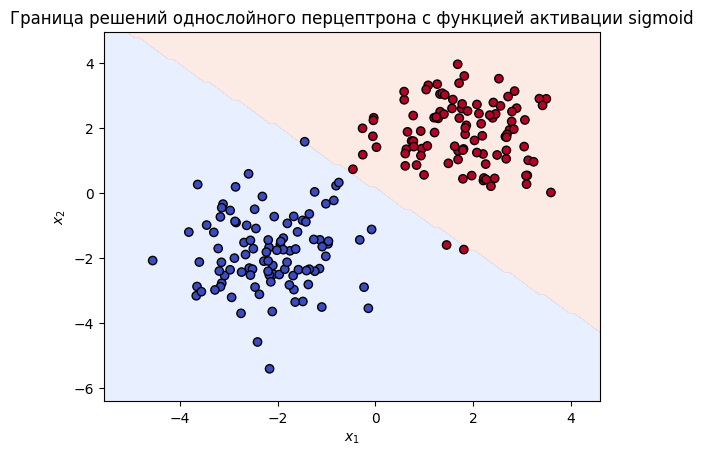

In [11]:
launch_learning_process(sigmoid)

Эпоха 1/10 — точность: 0.9850
Эпоха 2/10 — точность: 0.9950
Эпоха 3/10 — точность: 0.9900
Эпоха 4/10 — точность: 0.9850
Эпоха 5/10 — точность: 0.9800
Эпоха 6/10 — точность: 0.9750
Эпоха 7/10 — точность: 0.9750
Эпоха 8/10 — точность: 0.9750
Эпоха 9/10 — точность: 0.9650
Эпоха 10/10 — точность: 0.9650


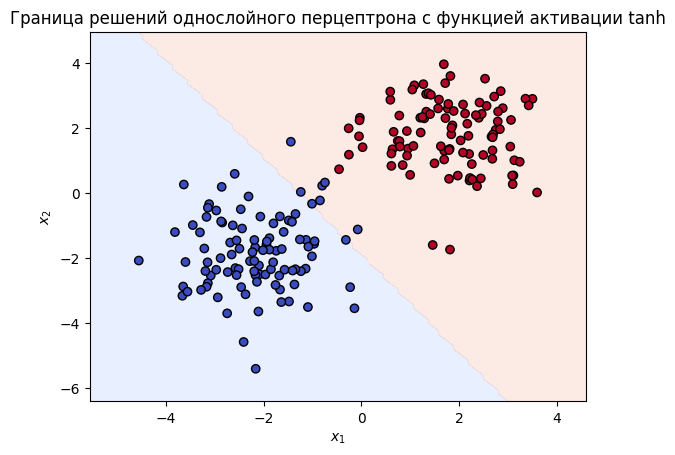

In [12]:
launch_learning_process(tanh)

Эпоха 1/10 — точность: 0.9850
Эпоха 2/10 — точность: 1.0000
Эпоха 3/10 — точность: 0.9950
Эпоха 4/10 — точность: 0.9900
Эпоха 5/10 — точность: 0.9850
Эпоха 6/10 — точность: 0.9850
Эпоха 7/10 — точность: 0.9800
Эпоха 8/10 — точность: 0.9800
Эпоха 9/10 — точность: 0.9800
Эпоха 10/10 — точность: 0.9800


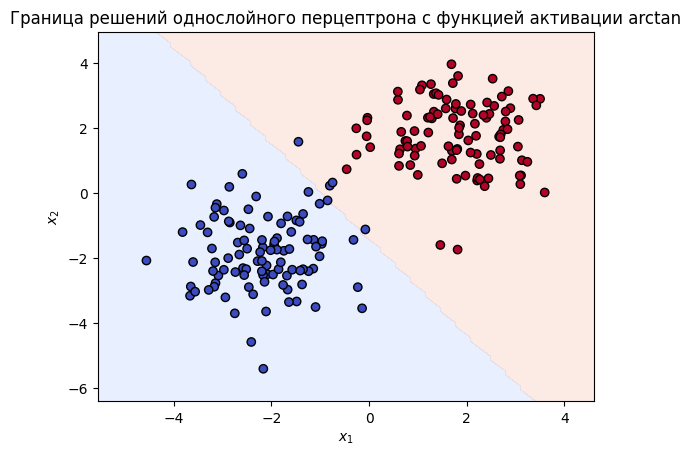

In [13]:
launch_learning_process(arctan)

Эпоха 1/10 — точность: 0.7750
Эпоха 2/10 — точность: 0.8600
Эпоха 3/10 — точность: 0.9000
Эпоха 4/10 — точность: 0.9400
Эпоха 5/10 — точность: 0.9500
Эпоха 6/10 — точность: 0.9700
Эпоха 7/10 — точность: 0.9800
Эпоха 8/10 — точность: 0.9800
Эпоха 9/10 — точность: 0.9850
Эпоха 10/10 — точность: 0.9900


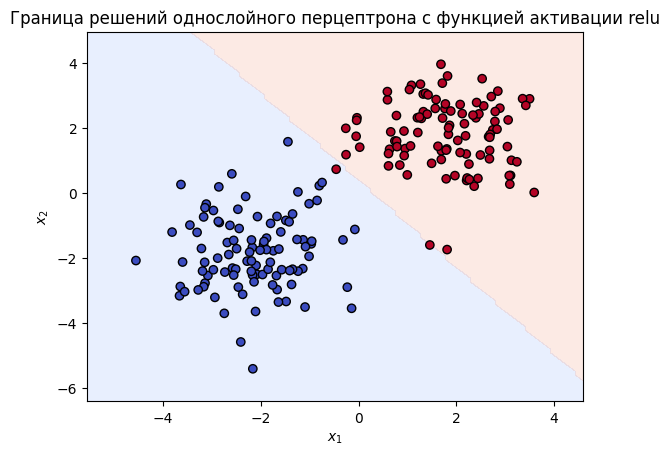

In [14]:
launch_learning_process(relu)

В целом, модель более-менее обучается с любой функцией активации (если, конечно, округлять предсказания до 0 и 1).

# Задание 3: вопросы

1. Что делает функция активации в искусственном нейроне?
- Вводит нелинейность в работу нейрона и нейросети в целом, поскольку класс линейных функций замкнут относительно композиции и, следовательно, нейросеть, состоящая из линейных нейронов, не сможет выучивать нелинейные зависимости. А также нормализует выход, если взвешенная сумма слишком большая или маленькая.
2. Чем отличается искусственный нейрон от однослойного перцептрона?
- Искуственный нейрон - это просто модель биологического нейрона, взвешенный сумматор с функцией активации, неспособный обучаться каким-либо задачам сам по себе. Однослойный перцептрон - это полноценная модель нейросети, состоящая из целого слоя таких нейронов и способная обучаться задаче бинарной классификации, если данные линейно разделимы.
3. Какое правило используется для обучения перцептрона?
- $w_i = w_i + η * (y_{true} - y_{pred}) * x_i$, где:
- $w_i$ — i-й вес нейрона,
- $x_i$ — соответствующий вход,
- $\eta$ — скорость обучения,
- $y_{true}$ — истинное значение,
- $y_{pred}$ — предсказанное.
4. Почему однослойный перцептрон не может решить задачу XOR?
- Потому что в задаче XOR данные не разделимы линейно. Невозможно разделить плоскость прямой так, чтобы точки (0, 0) и (1, 1) находились по одну сторону от нее, а точки (0, 1) и (1, 0) - по другую.
5. Что произойдет, если изменить функцию активации с сигмоиды на ReLU?
- В данной задаче это не имеет смысла, поскольку нам нужно предсказать вероятность, с которой вход принадлежит к 1-му классу (и, соответственно, не принадлежит ко 2-му). Модель все равно будет обучаться, но в случае 1-го класса вместо вероятности будут часто получаться какие-нибудь числа больше 1.